In [38]:
import pandas as pd
%matplotlib inline

data = pd.read_csv("condemned_properties.csv")

# C/D-E Prop - Data Gathering
#### Here, different sets of data are calculated to prove which neighborhood has the least and less serious run-down buildings.
##### The data (per neighborhood) includes:
* Number of Total Properties (AKA all Condemned and Dead-End Properties)
* Number of Last FAILED Inspections
* Number of Last PASSED Inspections
* Average Number of Last PASSED Inspections (per C&D-E Property)
* Cumulative Inspection Score (for all C&D-E Property)
* Average Inspection Score (per C&D-E Property)
* __Average Score (0-1) of ALL TESTS__

In [145]:
# This dataset just holds the total number of condemned/dead-end properties per neighborhood
nh = data['neighborhood'].value_counts().sort_values(ascending=True)

# This dataset holds the number of failed inspections of those properties per neighborhood
nh_fails = data[data['latest_inspection_result']=='Fail']
nh_fails = nh_fails['neighborhood'].value_counts().sort_values(ascending=True)

# This dataset holds the number of passed inspections of those properties per neighborhood
nh_passes = data[data['latest_inspection_result']=='Pass']
nh_passes = nh_passes['neighborhood'].value_counts().sort_values(ascending=False)

# This dataset holds the average rate of having a passing inspection per neighborhood
nh_avgs = nh_passes / nh
nh_avgs = nh_avgs.fillna(0)
nh_avgs = nh_avgs.sort_values(ascending=False)

# This dataset holds the cumulative inspection scores of each neighborhood
nh_scores = data.groupby('neighborhood')['latest_inspection_score'].sum().sort_values(ascending=False)

# This dataset holds the average inspection scores of each neighborhood
nh_score_avgs = data.groupby('neighborhood')['latest_inspection_score'].mean().sort_values(ascending=False)


# Big Average of all graph data

t = 1.0 - (nh / nh.max())
f = 1.0 - (nh_fails / nh_fails.max())
p = nh_passes / nh_passes.max()
a = nh_avgs / nh_avgs.max()
s = nh_scores / nh_scores.max()
v = nh_score_avgs / nh_score_avgs.max()

data_sum = t + f + p #+ a + s + v
tf = (t + f).fillna(0)
tfp = (tf + p).fillna(0)
tfpa = (tfp + a).fillna(0)
tfpas = (tfpa + s).fillna(0)
tfpasv = (tfpas + v).fillna(0)

total_nh_avgs = tfpasv / 6 #6
total_nh_avgs = total_nh_avgs.sort_values(ascending=False)

# C/D-E Prop - Example Graphs
#### These graphs condense all the information into just a few neighborhoods to be more easily digestible

<Axes: title={'center': 'Total Number of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Condemned/Dead-End Properties'>

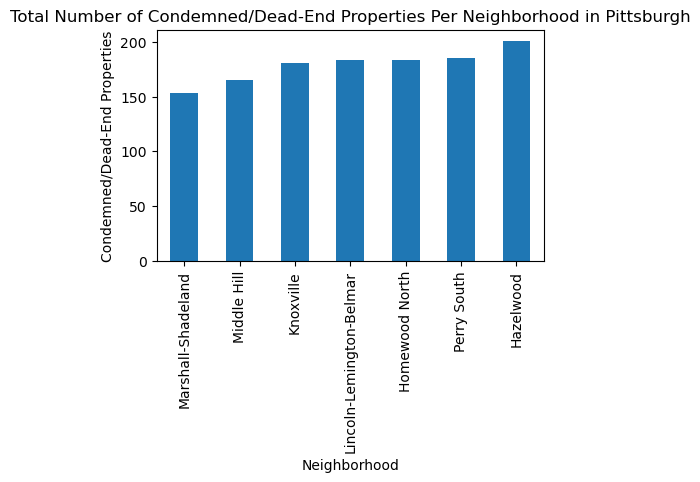

In [167]:
# Gets 7 highest amounts of C/D-E Properties
all_check = nh.tail(7)
all_check.plot(
    kind = "bar",
    title="Total Number of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Condemned/Dead-End Properties",
    figsize=(5,3)
)

<Axes: title={'center': 'Number of Passing Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Passing Inspections'>

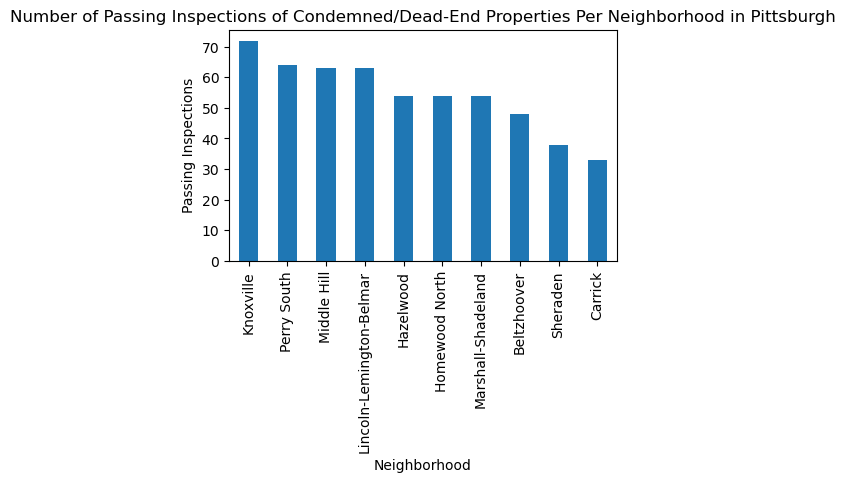

In [175]:
# Gets 10 highest amounts of Inspection Passes of C/D-E Properties
passes_check = nh_passes.head(10)
passes_check.plot(
    kind = "bar",
    title="Number of Passing Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Passing Inspections",
    figsize=(5,3)
)

<Axes: title={'center': 'Number of Failed Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Failed Inspections'>

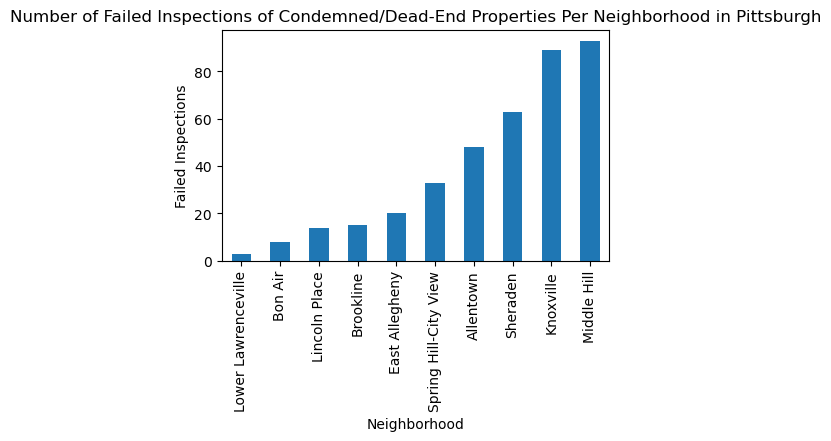

In [185]:
# Gets 10 random neighborhood amounts of Inspection Fails of C/D-E Properties
fails_check = nh_fails.sample(10)
fails_check = fails_check.sort_values(ascending=True)
fails_check.plot(
    kind = "bar",
    title="Number of Failed Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Failed Inspections",
    figsize=(5,3)
)

<Axes: title={'center': 'Average Test Score of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Average Test Scores'>

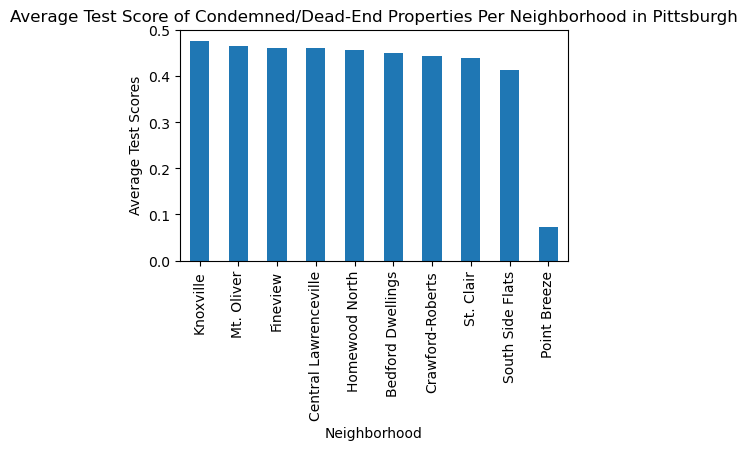

In [184]:
tot_avgs_check = total_nh_avgs.sample(10) 
tot_avgs_check = tot_avgs_check.sort_values(ascending=False)
tot_avgs_check.plot(
    kind = "bar",
    title="Average Test Score of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Average Test Scores",
    figsize=(5,3)
)

# C/D-E Prop - Complete Graphing
#### All the data calculated with the Data Gathering code is each put into their own simple bar graph.

<Axes: title={'center': 'Total Number of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Condemned/Dead-End Properties'>

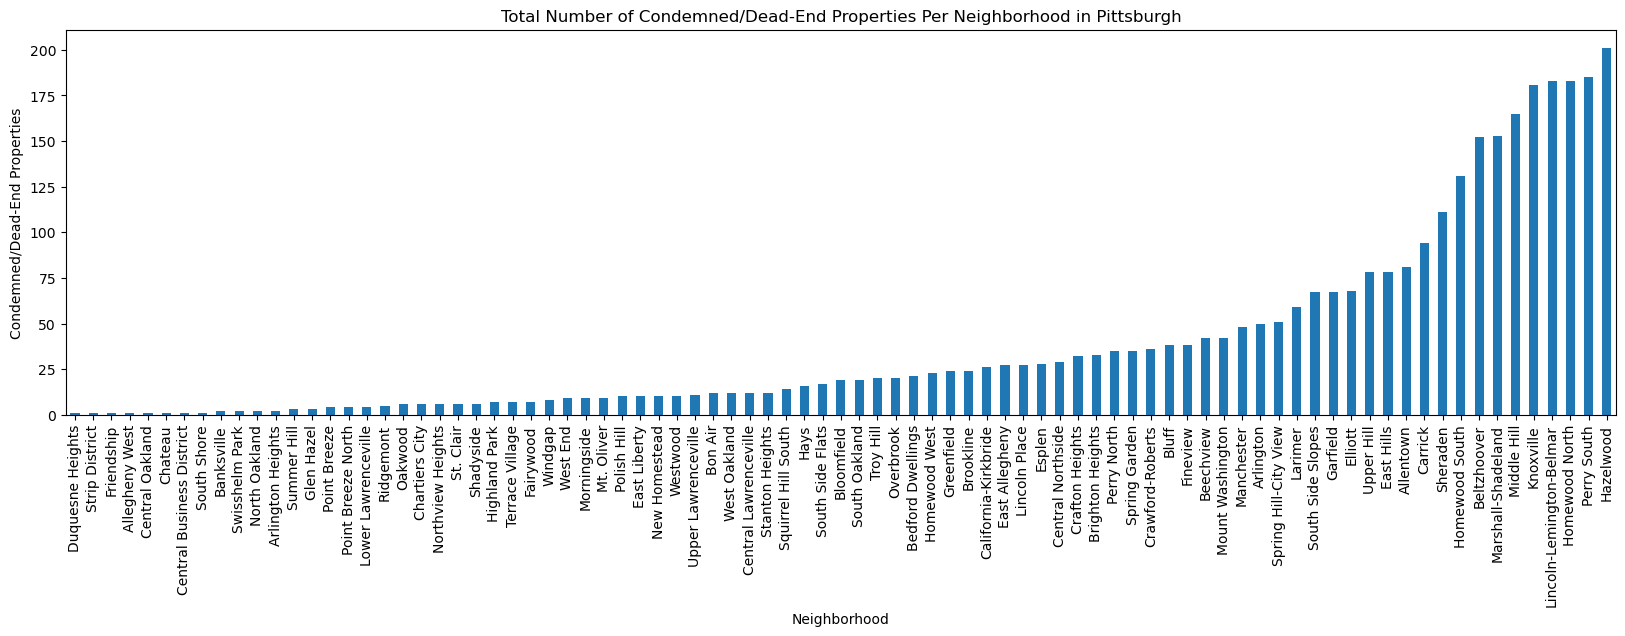

In [154]:
nh.plot(
    kind = "bar",
    title="Total Number of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Condemned/Dead-End Properties",
    figsize=(20,5)
)

<Axes: title={'center': 'Number of Failed Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Failed Inspections for Condemned/Dead-End Properties'>

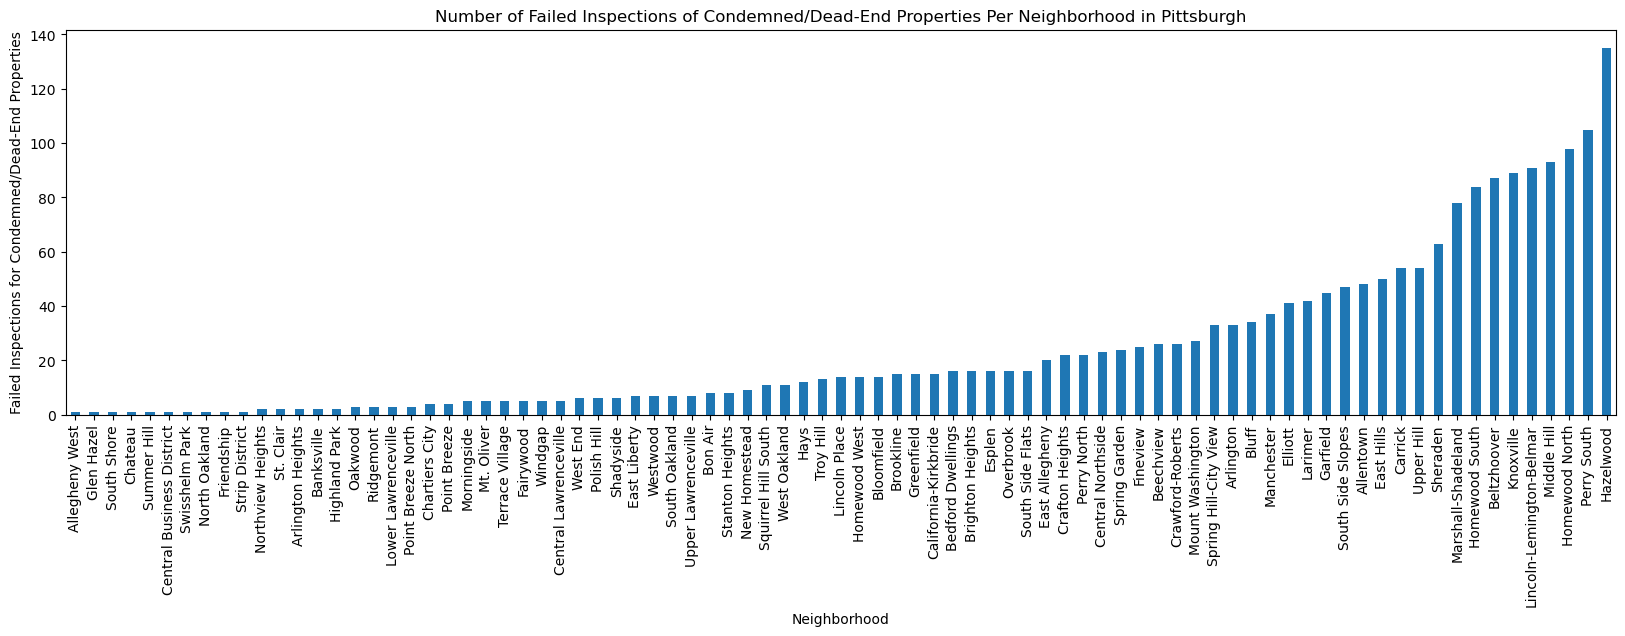

In [105]:
nh_fails.plot(
    kind = "bar",
    title="Number of Failed Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Failed Inspections for Condemned/Dead-End Properties",
    figsize=(20,5)
)

<Axes: title={'center': 'Number of Passing Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Passing Inspections for Condemned/Dead-End Properties'>

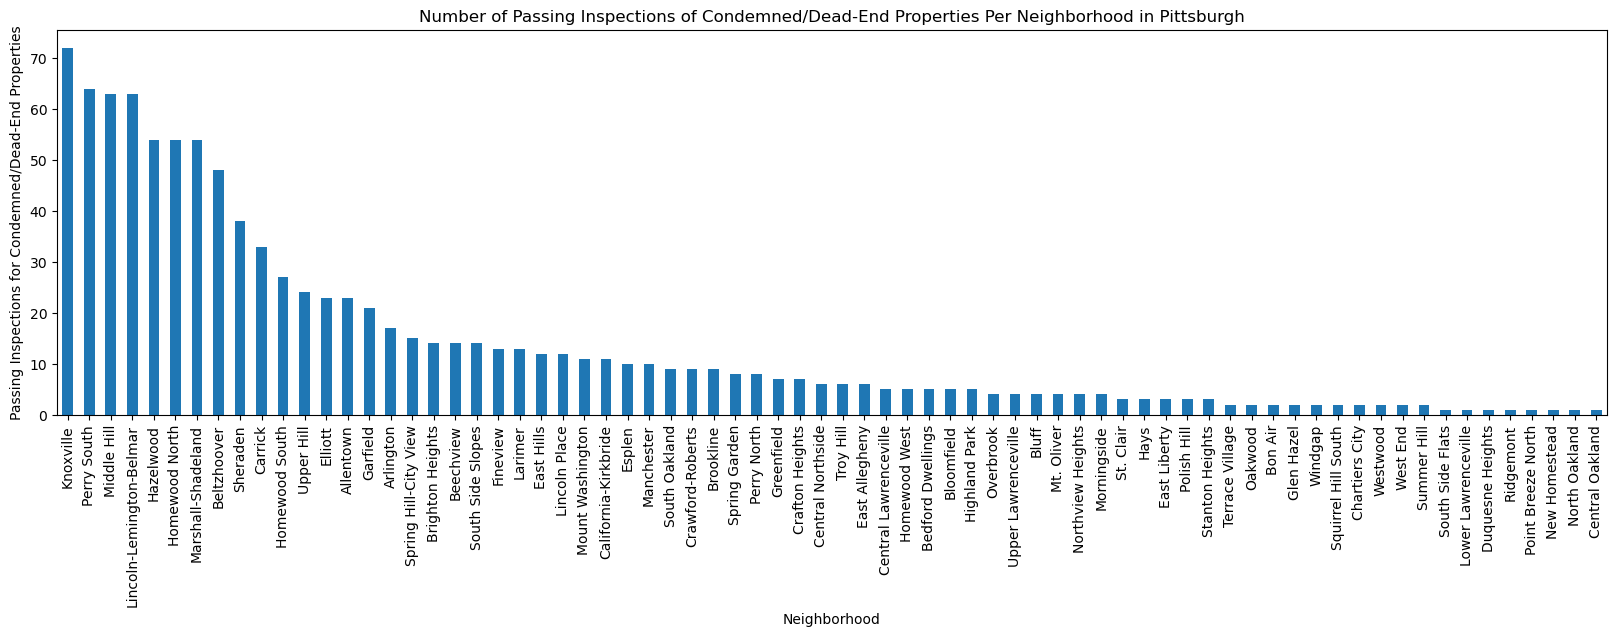

In [59]:
nh_passes.plot(
    kind = "bar",
    title="Number of Passing Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Passing Inspections for Condemned/Dead-End Properties",
    figsize=(20,5)
)

<Axes: title={'center': 'Average Number of Passing Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Average Passing Inspections for Condemned/Dead-End Properties'>

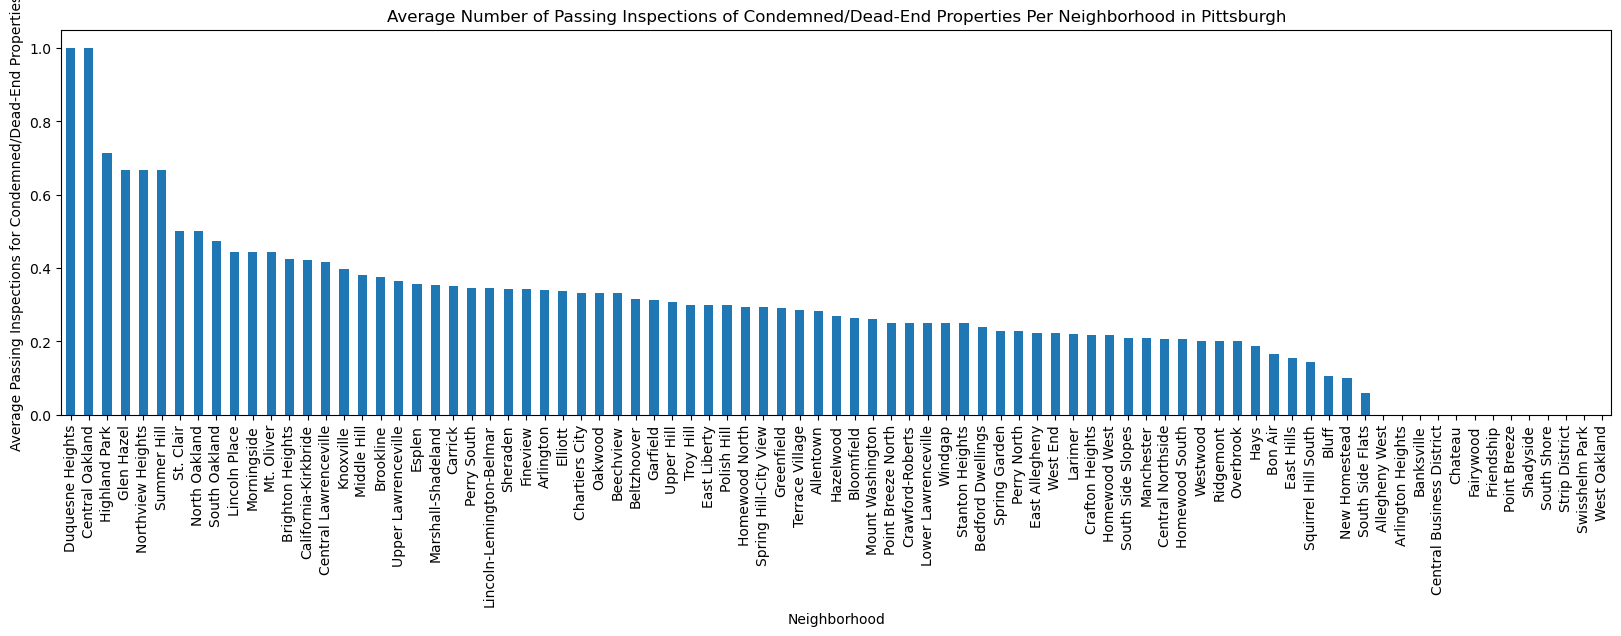

In [93]:
nh_avgs.plot(
    kind = "bar",
    title="Average Number of Passing Inspections of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Average Passing Inspections for Condemned/Dead-End Properties",
    figsize=(20,5)
)

<Axes: title={'center': 'Inspection Scores of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Total Scores for Condemned/Dead-End Properties'>

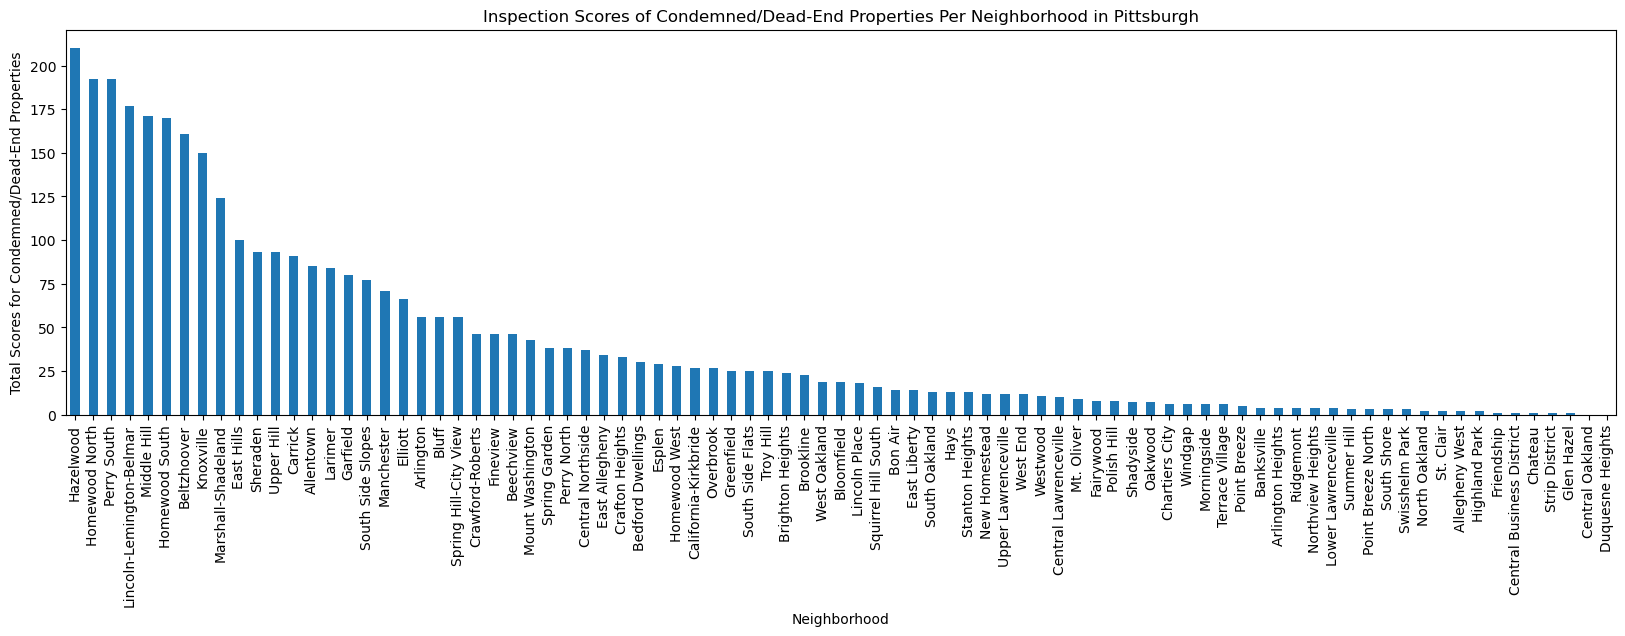

In [94]:
nh_scores.plot(
    kind = "bar",
    title="Inspection Scores of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Total Scores for Condemned/Dead-End Properties",
    figsize=(20,5)
)

<Axes: title={'center': 'Average Inspection Scores of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Average Scores for Condemned/Dead-End Properties'>

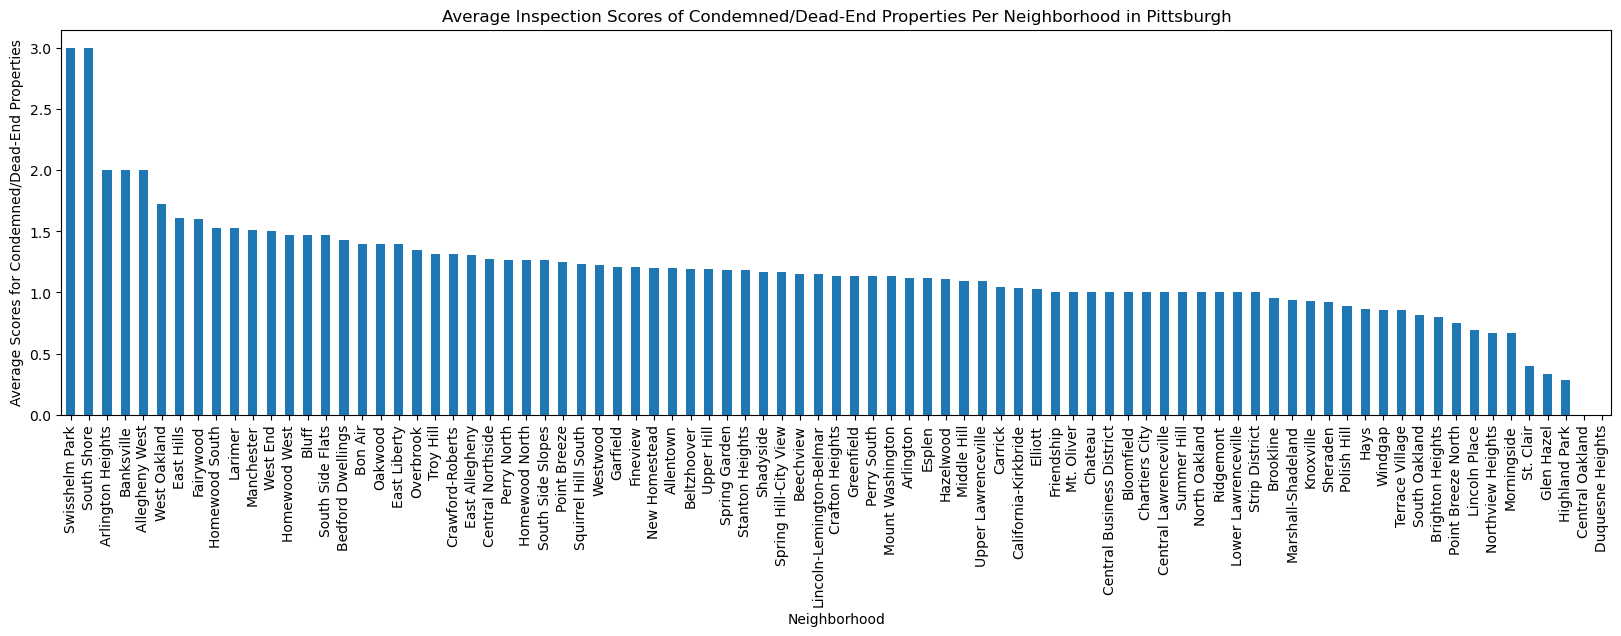

In [95]:
nh_score_avgs.plot(
    kind = "bar",
    title="Average Inspection Scores of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Average Scores for Condemned/Dead-End Properties",
    figsize=(20,5)
)

<Axes: title={'center': 'Average Test Score of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh'}, xlabel='Neighborhood', ylabel='Average Test Scores for Condemned/Dead-End Properties'>

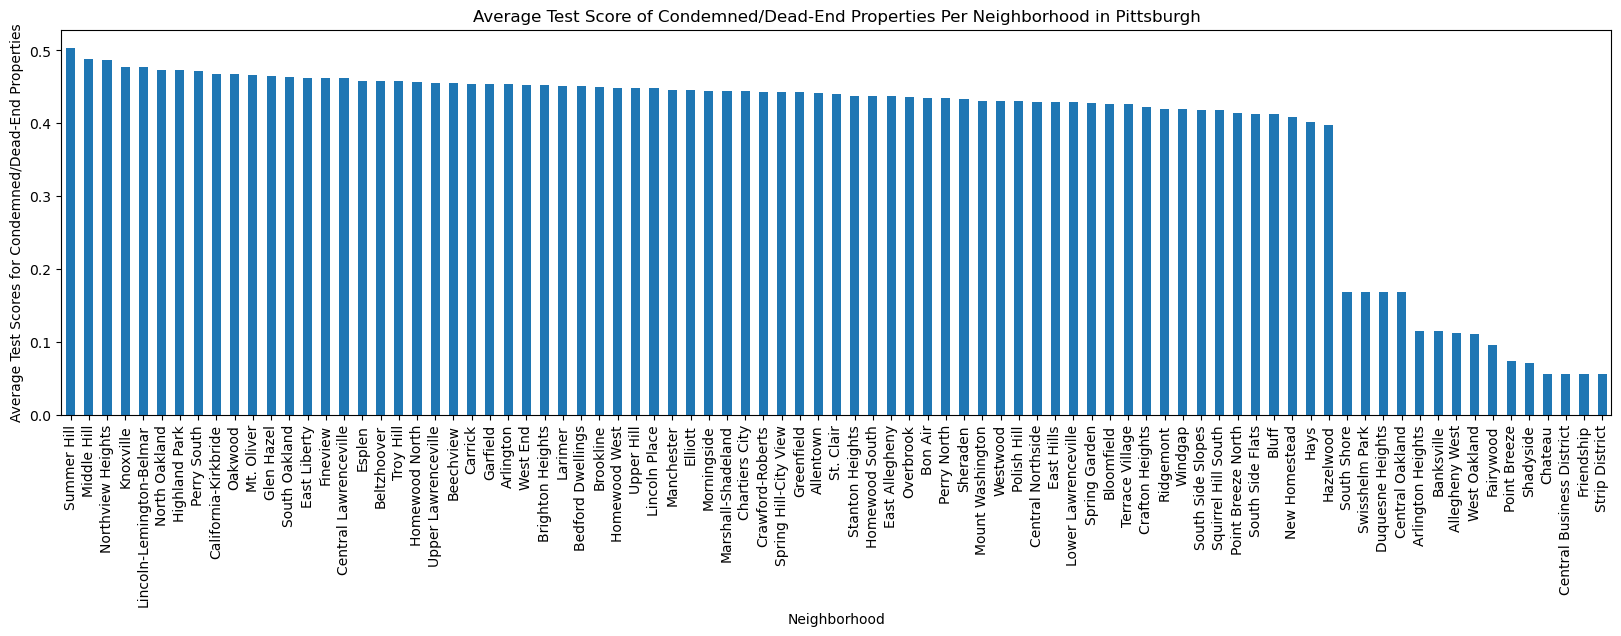

In [147]:
total_nh_avgs.plot(
    kind = "bar",
    title="Average Test Score of Condemned/Dead-End Properties Per Neighborhood in Pittsburgh",
    xlabel="Neighborhood",
    ylabel="Average Test Scores for Condemned/Dead-End Properties",
    figsize=(20,5)
)

The above code features outliers on the far side of the graph. Those outliers have a low score because they did not have enough properties to be considered in some of tests. For example, for the "Fail" and "Pass" inspection tests, some of these outliers did not have any condemned or dead-end property that Passed or Failed.

That might be because that neighborhood is genuinely better and has less run-down properties OR it is because they are smaller so they have less run-down properties.